# Mall Customer Clustering - using DBSCAN

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [19]:
df = pd.read_csv("/home/ipartzix/ML_Dataset/Mall_Customers.csv")
df.shape

(200, 5)

In [20]:
df = df.drop(columns="CustomerID")

In [21]:
df.head(5)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [22]:
X = df.iloc[:, [2, 3]].values

In [23]:
X.shape

(200, 2)

In [24]:
df.head(5)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [ ]:
db = DBSCAN(eps=3, min_samples=4, metric="euclidean")


In [26]:
model = db.fit(X)

In [27]:
label = model.labels_

In [28]:
label

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1,  0,  0,  0,  0, -1, -1,  0, -1,  0, -1,  0,  0,
       -1,  0, -1, -1,  0, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  2,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  2,
        3,  3, -1,  3, -1, -1,  4, -1, -1, -1,  4,  5,  4, -1,  4,  5, -1,
        5,  4, -1,  4,  5, -1, -1,  6, -1, -1, -1,  7, -1,  6, -1,  6, -1,
        7, -1,  6, -1,  7, -1,  7, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        8, -1,  8, -1,  8, -1,  8, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [29]:
from sklearn import metrics

# identifying the points which makes up our core points
sample_cores = np.zeros_like(label, dtype=bool)

sample_cores[db.core_sample_indices_] = True

# Calculating the number of clusters

n_clusters = len(set(label)) - (1 if -1 in label else 0)
print("No of clusters:", n_clusters)

No of clusters: 9


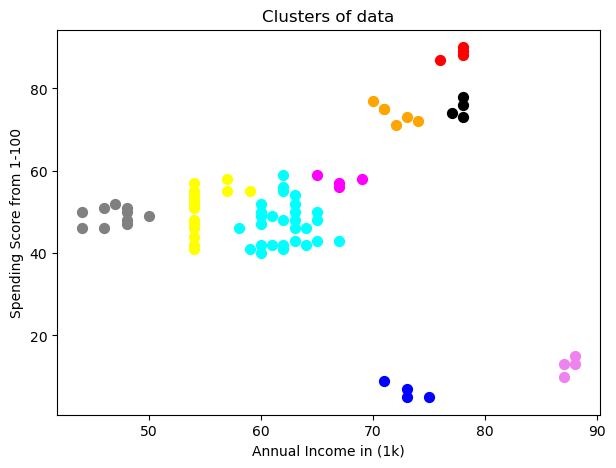

In [30]:
y_means = db.fit_predict(X)
plt.figure(figsize=(7, 5))
plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1], s=50, c="gray")
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1], s=50, c="yellow")
plt.scatter(X[y_means == 2, 0], X[y_means == 2, 1], s=50, c="cyan")
plt.scatter(X[y_means == 3, 0], X[y_means == 3, 1], s=50, c="magenta")
plt.scatter(X[y_means == 4, 0], X[y_means == 4, 1], s=50, c="orange")
plt.scatter(X[y_means == 5, 0], X[y_means == 5, 1], s=50, c="blue")
plt.scatter(X[y_means == 6, 0], X[y_means == 6, 1], s=50, c="red")
plt.scatter(X[y_means == 7, 0], X[y_means == 7, 1], s=50, c="black")
plt.scatter(X[y_means == 8, 0], X[y_means == 8, 1], s=50, c="violet")
plt.xlabel("Annual Income in (1k)")
plt.ylabel("Spending Score from 1-100")
plt.title("Clusters of data")
plt.show()